In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import re

In [7]:
df = pd.read_csv('../data/raw/Road Accident Data.csv')

In [8]:
df.head()

,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,BS0000001,01-01-2021,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,3:11:00 PM,Urban,Fine no high winds,Car
1,BS0000002,01-05-2021,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59:00 AM,Urban,Fine no high winds,Taxi/Private hire car
2,BS0000003,01-04-2021,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,2:19:00 PM,Urban,Fine no high winds,Taxi/Private hire car
3,BS0000004,01-05-2021,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,8:10:00 AM,Urban,Other,Motorcycle over 500cc
4,BS0000005,01-06-2021,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,5:25:00 PM,Urban,Fine no high winds,Car


In [9]:
df.isnull().sum()

Accident_Index                     0
Accident Date                      0
Day_of_Week                        0
Junction_Control                   0
Junction_Detail                    0
Accident_Severity                  0
Latitude                           0
Light_Conditions                   0
Local_Authority_(District)         0
Carriageway_Hazards           302549
Longitude                          0
Number_of_Casualties               0
Number_of_Vehicles                 0
Police_Force                       0
Road_Surface_Conditions            0
Road_Type                          0
Speed_limit                        0
Time                              17
Urban_or_Rural_Area                0
Weather_Conditions                 0
Vehicle_Type                       0
dtype: int64

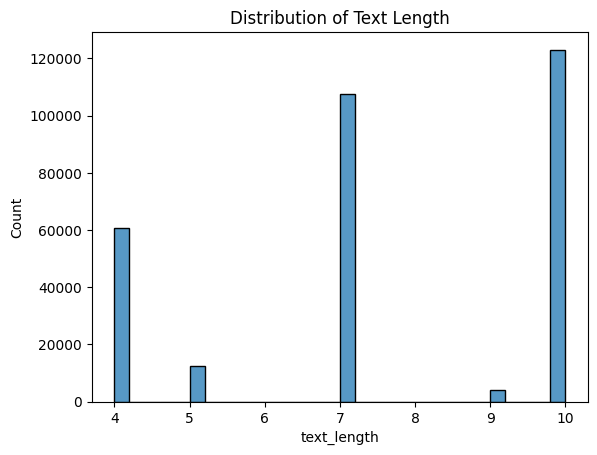

In [11]:
# Create a placeholder 'description' column for demonstration purposes
df['description'] = df['Accident_Severity'] + " accident at " + df['Junction_Detail']

# Calculate text length and plot the distribution
df['text_length'] = df['description'].apply(lambda x: len(str(x).split()))
sns.histplot(df['text_length'], bins=30)
plt.title('Distribution of Text Length')
plt.show()

In [13]:
from wordcloud import WordCloud
text = " ".join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

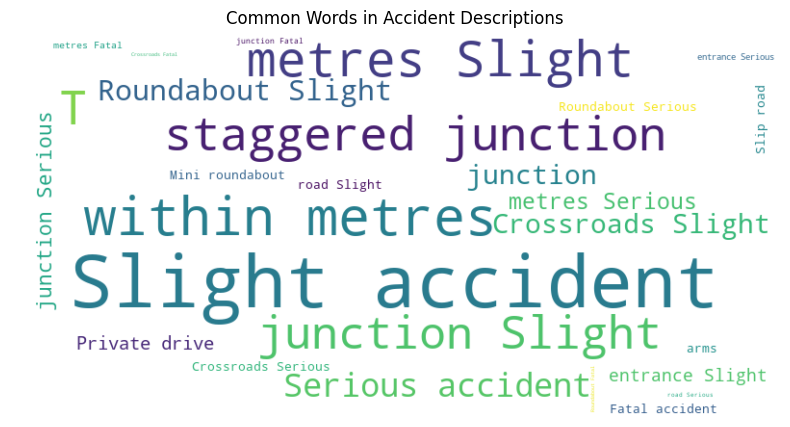

In [14]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Accident Descriptions')
plt.show()